# Customer Analysis

## Objective

This notebook provides a detailed analysis of the bank's customer base.
The analysis focuses on customer demographics, banking relationship,
financial characteristics, product usage, and customer segmentation.

### Key Business Questions

- What does the bank's customer base look like?
- How are customers distributed by geography and gender?
- What is the age profile of customers?
- How long have customers been associated with the bank?
- How many products do customers typically use?
- How many customers hold a credit card?
- How active are the bank's customers?
- What are the typical credit score, balance, and salary levels?
- Can customers be segmented based on their characteristics and behavior?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("../data/cleaned/bank_customer_churn_cleaned.csv")

In [3]:
data.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Customer Base**

In [5]:
total_customers = data["CustomerId"].nunique()
print(f"Total customers: {total_customers:,}")

Total customers: 10,000


**Customer-level summary**

In [6]:
customer_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Average Age",
        "Average Tenure",
        "Average Products",
        "Credit Card Ownership (%)",
        "Active Membership (%)"
    ],
    "Value": [
        data["CustomerId"].nunique(),
        data["Age"].mean(),
        data["Tenure"].mean(),
        data["NumOfProducts"].mean(),
        data["HasCrCard"].mean() * 100,
        data["IsActiveMember"].mean() * 100
    ]
})

customer_summary

,Metric,Value
0,Total Customers,10000.0000
1,Average Age,38.9218
2,Average Tenure,5.0128
3,Average Products,1.5302
4,Credit Card Ownership (%),70.5500
5,Active Membership (%),51.5100


**Age Distribution**

In [49]:
data["Age"].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

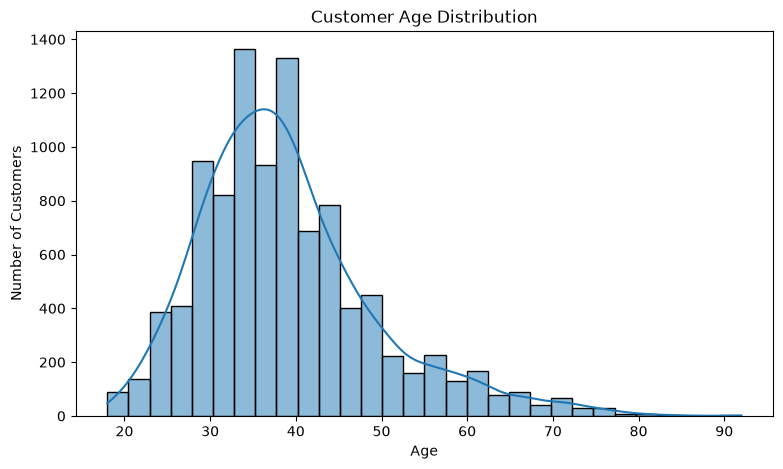

In [47]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=data,
    x="Age",
    bins=30,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

In [7]:
data["Age_Group"] = pd.cut(
    data["Age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "66+"
    ]
)

In [8]:
age_group_summary = (
    data["Age_Group"]
    .value_counts()
    .sort_index()
    .reset_index()
)

age_group_summary.columns = ["Age Group", "Customers"]

age_group_summary["Percentage"] = (
    age_group_summary["Customers"]
    / len(data)
    * 100
).round(2)

age_group_summary

,Age Group,Customers,Percentage
0,18-25,611,6.11
1,26-35,3542,35.42
2,36-45,3736,37.36
3,46-55,1311,13.11
4,56-65,536,5.36
5,66+,264,2.64


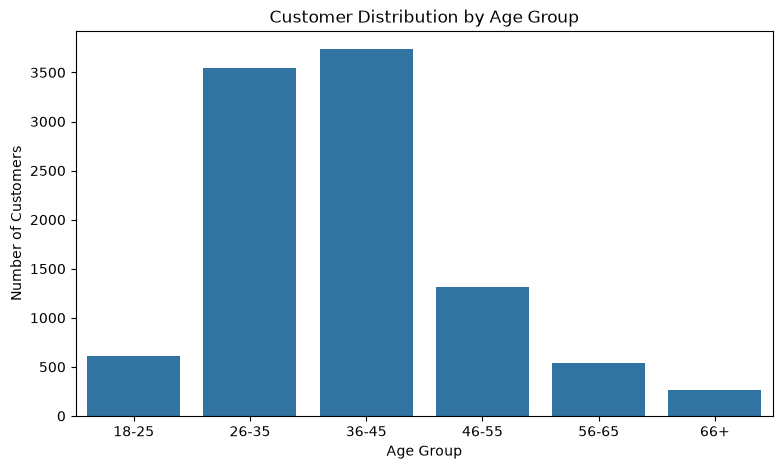

In [9]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=data,
    x="Age_Group"
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.show()

## Gender Analysis

**Customer count by gender**

In [56]:
gender_summary = (
    data["Gender"]
    .value_counts()
    .reset_index()
)

gender_summary.columns = ["Gender", "Customers"]

gender_summary["Percentage"] = (
    gender_summary["Customers"]
    / len(data)
    * 100
).round(2)

gender_summary

,Gender,Customers,Percentage
0,Male,5457,54.57
1,Female,4543,45.43


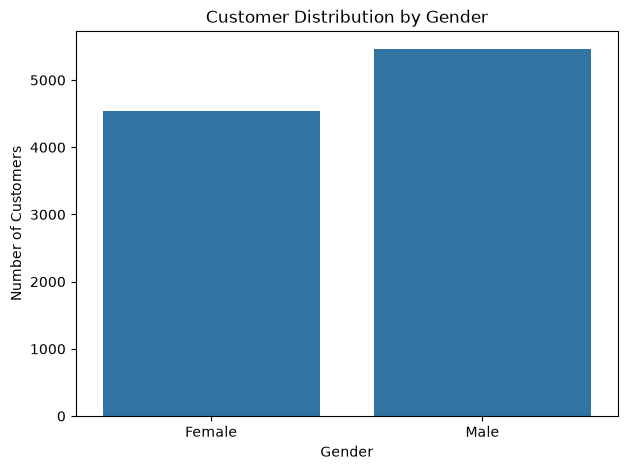

In [57]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="Gender"
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

## Geographic Analysis

**Customers by Geography**

In [58]:
geography_summary = (
    data["Geography"]
    .value_counts()
    .reset_index()
)

geography_summary.columns = ["Geography", "Customers"]

geography_summary["Percentage"] = (
    geography_summary["Customers"]
    / len(data)
    * 100
).round(2)

geography_summary

,Geography,Customers,Percentage
0,France,5014,50.14
1,Germany,2509,25.09
2,Spain,2477,24.77


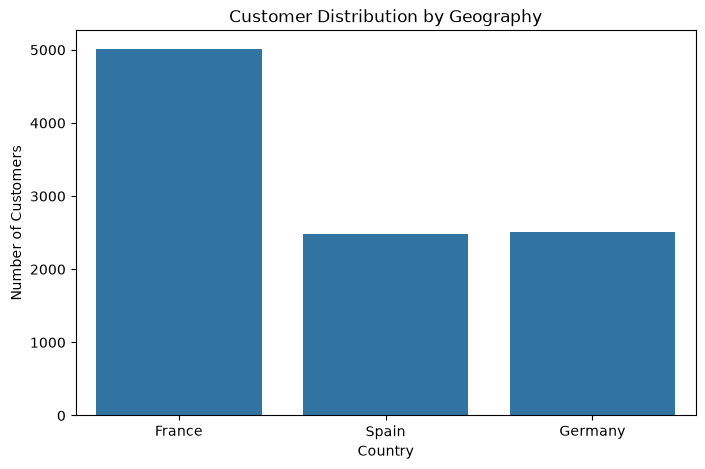

In [59]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="Geography"
)

plt.title("Customer Distribution by Geography")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.show()

## Customer Tenure Analysis 
Tenure means: The number of years the customer has been with the bank.

In [60]:
data["Tenure"].describe() 

count    10000.000000
mean         5.012800
std          2.892174
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: Tenure, dtype: float64

**Tenure distribution**

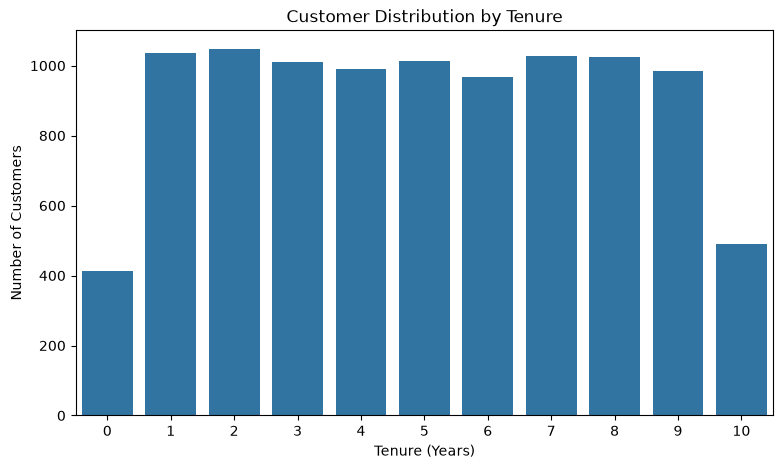

In [61]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=data,
    x="Tenure"
)

plt.title("Customer Distribution by Tenure")
plt.xlabel("Tenure (Years)")
plt.ylabel("Number of Customers")
plt.show()

**Average tenure by geography**

In [62]:
tenure_by_geography = (
    data.groupby("Geography")["Tenure"]
    .agg(["count", "mean", "median"])
    .round(2)
    .sort_values("mean", ascending=False)
)

tenure_by_geography

,count,mean,median
Geography,,,
Spain,2477,5.03,5.0
Germany,2509,5.01,5.0
France,5014,5.00,5.0


**Finding** 
"Average customer tenure is approximately 5 years across all three countries, indicating little geographic variation in relationship duration."

## Product Usage Analysis

**Number of Products**(NumOfProducts tells us how many banking products/services each customer has with the bank.)

In [63]:
product_summary = (
    data["NumOfProducts"]
    .value_counts()
    .sort_index()
    .reset_index()
)

product_summary.columns = ["Number of Products", "Customers"]

product_summary["Percentage"] = (
    product_summary["Customers"]
    / len(data)
    * 100
).round(2)

product_summary

,Number of Products,Customers,Percentage
0,1,5084,50.84
1,2,4590,45.90
2,3,266,2.66
3,4,60,0.60


**Finding**   "Nearly 97% of customers hold either one or two banking products, indicating that deeper product penetration is concentrated among a very small share of customers."

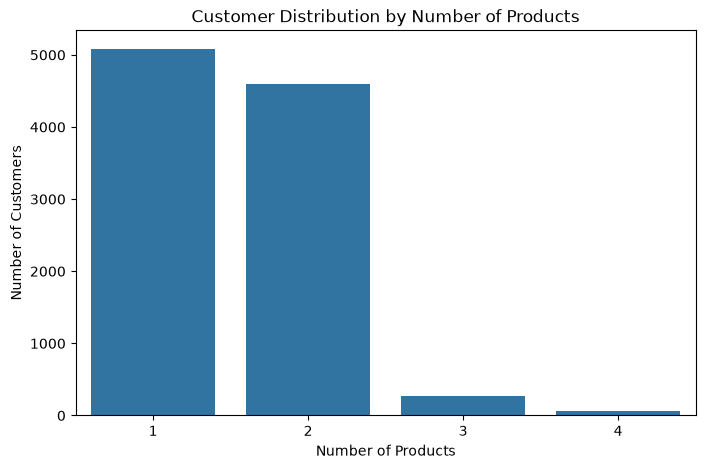

In [64]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="NumOfProducts"
)

plt.title("Customer Distribution by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")
plt.show()

**Average products by geography**

In [66]:
products_by_geography = (
    data.groupby("Geography")["NumOfProducts"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

products_by_geography

Geography
Spain      1.54
France     1.53
Germany    1.52
Name: NumOfProducts, dtype: float64

## Credit Card Ownership

In [67]:
credit_card_summary = (
    data["HasCrCard"]
    .map({
        0: "No Credit Card",
        1: "Has Credit Card"
    })
    .value_counts()
    .reset_index()
)

credit_card_summary.columns = ["Credit Card Status", "Customers"]

credit_card_summary["Percentage"] = (
    credit_card_summary["Customers"]
    / len(data)
    * 100
).round(2)

credit_card_summary

,Credit Card Status,Customers,Percentage
0,Has Credit Card,7055,70.55
1,No Credit Card,2945,29.45


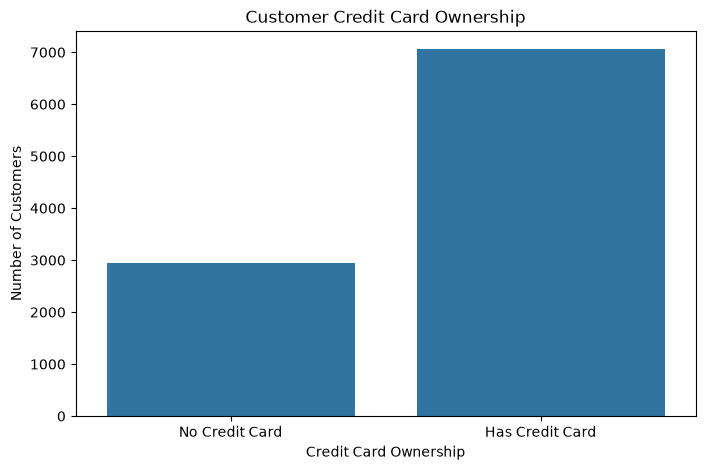

In [68]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="HasCrCard"
)

plt.title("Customer Credit Card Ownership")
plt.xlabel("Credit Card Ownership")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["No Credit Card", "Has Credit Card"])

plt.show()

## Active Member Analysis

In [69]:
activity_summary = (
    data["IsActiveMember"]
    .map({
        0: "Inactive Member",
        1: "Active Member"
    })
    .value_counts()
    .reset_index()
)

activity_summary.columns = ["Membership Status", "Customers"]

activity_summary["Percentage"] = (
    activity_summary["Customers"]
    / len(data)
    * 100
).round(2)

activity_summary

,Membership Status,Customers,Percentage
0,Active Member,5151,51.51
1,Inactive Member,4849,48.49


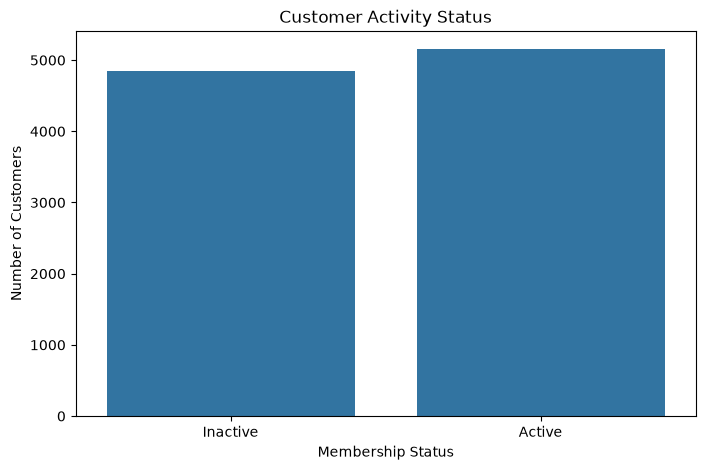

In [70]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="IsActiveMember"
)

plt.title("Customer Activity Status")
plt.xlabel("Membership Status")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["Inactive", "Active"])

plt.show()

## Credit Score Analysis

In [71]:
data["CreditScore"].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

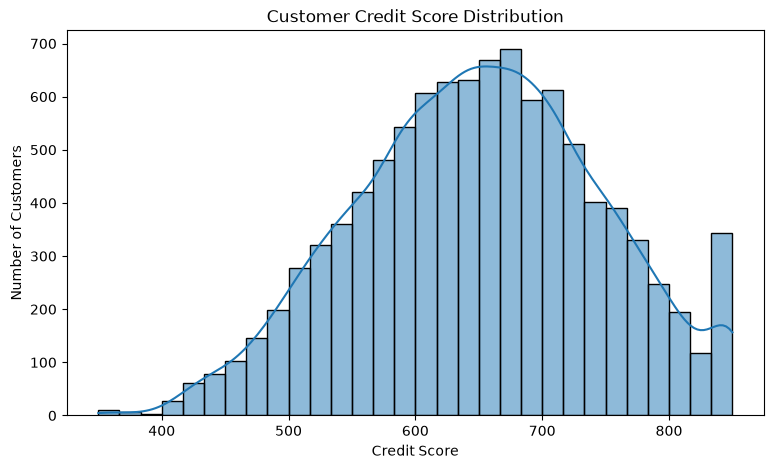

In [72]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=data,
    x="CreditScore",
    bins=30,
    kde=True
)

plt.title("Customer Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")
plt.show()

In [107]:
credit_score_by_geo = (
    data.groupby("Geography")["CreditScore"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

credit_score_by_geo

,mean,median,min,max
Geography,,,,
France,649.67,653.0,350,850
Germany,651.45,651.0,350,850
Spain,651.33,651.0,350,850


## Balance Analysis

In [74]:
data["Balance"].describe()

count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: Balance, dtype: float64

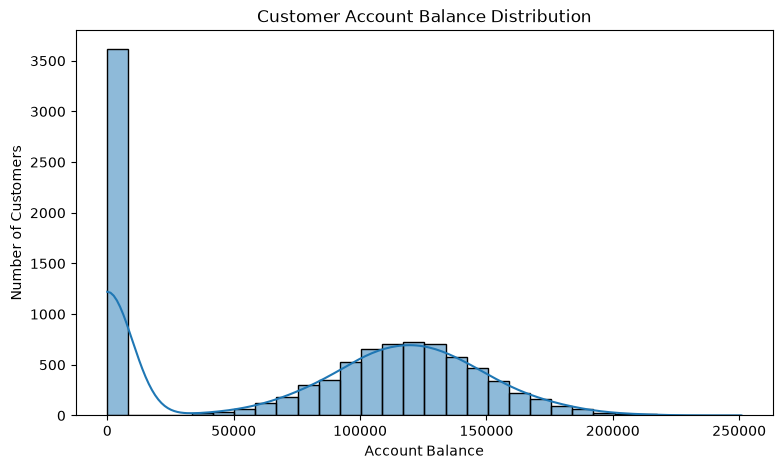

In [75]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=data,
    x="Balance",
    bins=30,
    kde=True
)

plt.title("Customer Account Balance Distribution")
plt.xlabel("Account Balance")
plt.ylabel("Number of Customers")
plt.show()

In [76]:
balance_by_geo = (
    data.groupby("Geography")["Balance"]
    .agg(["mean", "median", "sum"])
    .round(2)
    .sort_values("mean", ascending=False)
)

balance_by_geo

,mean,median,sum
Geography,,,
Germany,119730.12,119703.10,3.004029e+08
France,62092.64,62153.50,3.113325e+08
Spain,61818.15,61710.44,1.531236e+08


## Zero Balance Rate

In [10]:
zero_balance_rate = (data["Balance"] == 0).mean() * 100
print(f"Zero-balance customers: {zero_balance_rate:.2f}%")

Zero-balance customers: 36.17%


## Estimated Salary Analysis

In [77]:
data["EstimatedSalary"].describe()

count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: EstimatedSalary, dtype: float64

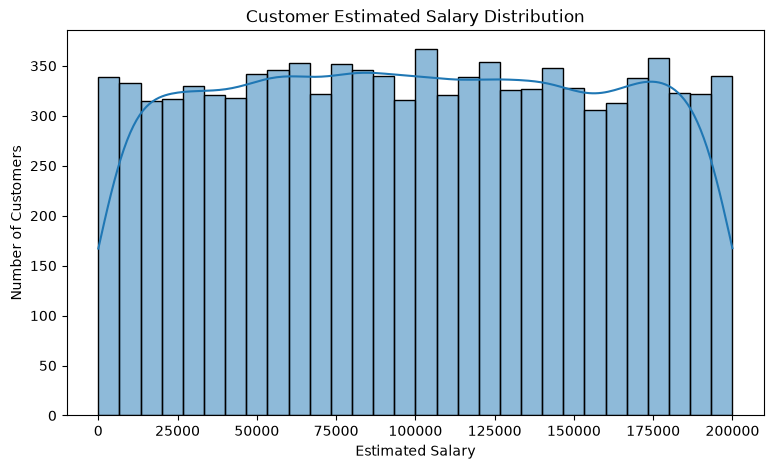

In [78]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=data,
    x="EstimatedSalary",
    bins=30,
    kde=True
)

plt.title("Customer Estimated Salary Distribution")
plt.xlabel("Estimated Salary")
plt.ylabel("Number of Customers")
plt.show()

In [79]:
salary_by_geo = (
    data.groupby("Geography")["EstimatedSalary"]
    .agg(["mean", "median"])
    .round(2)
    .sort_values("mean", ascending=False)
)

salary_by_geo

,mean,median
Geography,,
Germany,101113.44,102397.22
France,99899.18,99132.31
Spain,99440.57,99984.86


## Customer Financial Profile

In [83]:
financial_summary = data[
    ["CreditScore", "Balance", "EstimatedSalary"]
].describe()

financial_summary

,CreditScore,Balance,EstimatedSalary
count,10000.000000,10000.000000,10000.000000
mean,650.528800,76485.889288,100090.239881
std,96.653299,62397.405202,57510.492818
min,350.000000,0.000000,11.580000
25%,584.000000,0.000000,51002.110000
50%,652.000000,97198.540000,100193.915000
75%,718.000000,127644.240000,149388.247500
max,850.000000,250898.090000,199992.480000


## Customer Profile by Geography

In [86]:
geography_profile = (
    data.groupby("Geography")
    .agg(
        Customers=("CustomerId", "nunique"),
        Avg_Age=("Age", "mean"),
        Avg_Tenure=("Tenure", "mean"),
        Avg_Credit_Score=("CreditScore", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Salary=("EstimatedSalary", "mean"),
        Avg_Products=("NumOfProducts", "mean"),
        Active_Members=("IsActiveMember", "sum")
    )
    .round(2)
)
geography_profile["Active_Member_Rate"] = (
    geography_profile["Active_Members"]
    / geography_profile["Customers"]
    * 100
).round(2)

geography_profile

,Customers,Avg_Age,Avg_Tenure,Avg_Credit_Score,Avg_Balance,Avg_Salary,Avg_Products,Active_Members,Active_Member_Rate
Geography,,,,,,,,,
France,5014,38.51,5.00,649.67,62092.64,99899.18,1.53,2591,51.68
Germany,2509,39.77,5.01,651.45,119730.12,101113.44,1.52,1248,49.74
Spain,2477,38.89,5.03,651.33,61818.15,99440.57,1.54,1312,52.97


## Customer Profile by Gender

In [87]:
gender_profile = (
    data.groupby("Gender")
    .agg(
        Customers=("CustomerId", "nunique"),
        Avg_Age=("Age", "mean"),
        Avg_Tenure=("Tenure", "mean"),
        Avg_Credit_Score=("CreditScore", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Salary=("EstimatedSalary", "mean"),
        Avg_Products=("NumOfProducts", "mean")
    )
    .round(2)
)

gender_profile

,Customers,Avg_Age,Avg_Tenure,Avg_Credit_Score,Avg_Balance,Avg_Salary,Avg_Products
Gender,,,,,,,
Female,4543,39.24,4.97,650.83,75659.37,100601.54,1.54
Male,5457,38.66,5.05,650.28,77173.97,99664.58,1.52


## Customer Profile by Age Group

In [88]:
age_profile = (
    data.groupby("Age_Group", observed=True)
    .agg(
        Customers=("CustomerId", "nunique"),
        Avg_Credit_Score=("CreditScore", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Salary=("EstimatedSalary", "mean"),
        Avg_Products=("NumOfProducts", "mean"),
        Avg_Tenure=("Tenure", "mean")
    )
    .round(2)
)

age_profile

,Customers,Avg_Credit_Score,Avg_Balance,Avg_Salary,Avg_Products,Avg_Tenure
Age_Group,,,,,,
18-25,611,651.16,75095.80,102093.90,1.55,5.19
26-35,3542,650.50,74127.81,99733.15,1.54,5.03
36-45,3736,651.72,76830.51,100356.95,1.54,4.99
46-55,1311,645.77,81583.23,101729.51,1.47,5.03
56-65,536,646.66,81327.00,94369.66,1.50,4.82
65+,264,664.14,71321.86,99943.62,1.52,5.09


## Customer Segmentation — Product Engagement

In [89]:
data["Product_Segment"] = np.select(
    [
        data["NumOfProducts"] == 1,
        data["NumOfProducts"] == 2,
        data["NumOfProducts"] >= 3
    ],
    [
        "Single Product",
        "Two Products",
        "Multi-Product"
    ],
    default="Unknown"
)

data["Product_Segment"].value_counts()

Product_Segment
Single Product    5084
Two Products      4590
Multi-Product      326
Name: count, dtype: int64

## Customer Segmentation — Engagement

In [90]:
data["Engagement_Segment"] = np.where(
    data["IsActiveMember"] == 1,
    "Active Customer",
    "Inactive Customer"
)

data["Engagement_Segment"].value_counts()

Engagement_Segment
Active Customer      5151
Inactive Customer    4849
Name: count, dtype: int64

## Customer Segmentation — Balance

In [15]:
data["Balance_Group"] = pd.cut(
    data["Balance"],
    bins=[-1, 50000, 100000, 150000, 200000, np.inf],
    labels=[
        "0-50K",
        "50K-100K",
        "100K-150K",
        "150K-200K",
        "200K+"
    ]
)
data["Balance_Group"].value_counts().sort_index()

Balance_Group
0-50K        3692
50K-100K     1509
100K-150K    3830
150K-200K     935
200K+          34
Name: count, dtype: int64

## Customer Segmentation — Credit Score

In [14]:
data["Credit_Score_Segment"] = pd.cut(
    data["CreditScore"],
    bins=[0, 579, 669, 739, 799, 900],
    labels=[
        "Poor",
        "Fair",
        "Good",
        "Very Good",
        "Excellent"
    ]
)

data["Credit_Score_Segment"].value_counts().sort_index()

Credit_Score_Segment
Poor         2362
Fair         3331
Good         2428
Very Good    1224
Excellent     655
Name: count, dtype: int64

### Customer Segment Summary

In [98]:
customer_segment_summary = (
    data.groupby(
        ["Product_Segment", "Engagement_Segment"],
        observed=True
    )
    .agg(
        Customers=("CustomerId", "nunique"),
        Avg_Age=("Age", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Credit_Score=("CreditScore", "mean"),
        Avg_Salary=("EstimatedSalary", "mean")
    )
    .round(2)
    .sort_values("Customers", ascending=False)
)

customer_segment_summary

Customers  Avg_Age  Avg_Balance  \
Product_Segment Engagement_Segment                                    
Single Product  Active Customer          2563    40.25     98902.02   
                Inactive Customer        2521    39.09     98195.89   
Two Products    Active Customer          2446    39.09     51852.94   
                Inactive Customer        2144    36.23     51909.04   
Multi-Product   Inactive Customer         184    43.66     82498.74   
                Active Customer           142    43.65     74057.29   

                                    Avg_Credit_Score  Avg_Salary  
Product_Segment Engagement_Segment                                
Single Product  Active Customer               651.13    98140.10  
                Inactive Customer             647.08   100856.86  
Two Products    Active Customer               655.05   100468.10  
                Inactive Customer             648.93   100433.66  
Multi-Product   Inactive Customer             649.09   103425.36  
                Active Customer               649.15   105663.23

## Customer Characteristics Correlation

In [99]:
numeric_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

correlation_matrix = data[numeric_columns].corr()

correlation_matrix.round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
CreditScore,1.00,-0.00,0.00,0.01,0.01,-0.00
Age,-0.00,1.00,-0.01,0.03,-0.03,-0.01
Tenure,0.00,-0.01,1.00,-0.01,0.01,0.01
Balance,0.01,0.03,-0.01,1.00,-0.30,0.01
NumOfProducts,0.01,-0.03,0.01,-0.30,1.00,0.01
EstimatedSalary,-0.00,-0.01,0.01,0.01,0.01,1.00


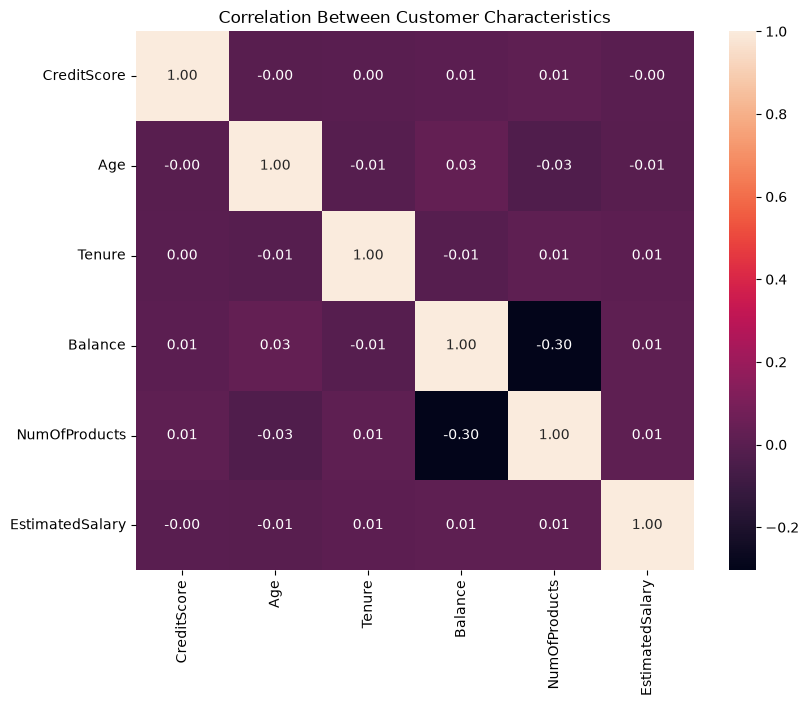

In [100]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Customer Characteristics")
plt.show()

# Key Customer Insights

### Customer Base
- The dataset contains a broad customer base distributed across multiple geographies.
- Customer characteristics vary across age, geography, financial profile, and banking engagement.

### Demographics
- The age distribution provides an overview of the bank's primary customer segments.
- Geographic and gender analysis highlights differences in customer composition.

### Banking Relationship
- Tenure analysis shows how long customers have maintained their relationship with the bank.
- Product ownership indicates the depth of customers' relationships with the bank.
- Credit card ownership provides an additional indicator of product adoption.
- Active membership reflects customer engagement with the bank.

### Financial Profile
- Credit score analysis provides an overview of customer credit quality.
- Balance analysis highlights differences in customer account holdings.
- Estimated salary provides an indication of the financial profile of the customer base.

### Customer Segmentation
- Customers can be segmented based on product usage, engagement, balance, and credit score.
- These segments can help the bank design more targeted products, services, and engagement strategies.

# Business Recommendations

1. **Strengthen customer engagement**
   - Develop targeted engagement campaigns for inactive customers.

2. **Increase product penetration**
   - Identify single-product customers and offer relevant complementary banking products.

3. **Use customer segmentation**
   - Create differentiated strategies based on customer balance, credit profile, age, and engagement.

4. **Develop geography-specific strategies**
   - Customer characteristics differ across countries, so product and engagement strategies should be adapted to local customer profiles.

5. **Focus on high-value customer segments**
   - Customers with higher balances and broader product relationships can be prioritized for premium services and relationship-management initiatives.

6. **Improve customer understanding**
   - Combine demographic, financial, and behavioral characteristics to develop more meaningful customer segments.